# 🧹 Limpieza de datos y EDA

## Contexto
El dataset crudo contiene 3.780 publicaciones de MercadoLibre con precios 
en dos monedas distintas (USD y ARS), kilómetros como texto y valores anómalos.
Antes de cualquier análisis necesitamos un dataset consistente y confiable.

## Objetivo de esta fase
- Unificar precios a una sola moneda (USD)
- Convertir kilómetros a variable numérica
- Detectar y eliminar outliers con criterio estadístico
- Explorar visualmente la distribución de precios y km por modelo

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from bs4 import BeautifulSoup

df = pd.read_csv("../data/raw/precios_autos_raw.csv")
print(f"Shape: {df.shape}")
print(f"\nTipos de datos:\n{df.dtypes}")
print(f"\nPrimeras filas:\n{df.head()}")

# Backup del dataset original para análisis de limpieza
df_raw = df.copy()

Shape: (3780, 7)

Tipos de datos:
modelo        object
titulo        object
precio       float64
moneda        object
año            int64
km            object
ubicacion     object
dtype: object

Primeras filas:
         modelo                           titulo      precio moneda   año  \
0  Toyota Etios       Toyota Etios 1.5 Sedan Xls     13200.0    US$  2018   
1  Toyota Etios       Toyota Etios 1.5 Sedan Xls  18100000.0      $  2018   
2  Toyota Etios       Toyota Etios 1.5 Sedan Xls  11500000.0      $  2016   
3  Toyota Etios             Toyota Etios 1.5 Xls     17000.0    US$  2021   
4  Toyota Etios  Toyota Etios 1.5 5 Ptas Xls 4at  18000000.0      $  2017   

           km                            ubicacion  
0   89.000 Km    Capital Federal - Capital Federal  
1  133.000 Km    Capital Federal - Capital Federal  
2  101.000 Km       Avellaneda - Bs.As. G.B.A. Sur  
3   80.000 Km     San Miguel - Bs.As. G.B.A. Norte  
4   47.000 Km  Vicente López - Bs.As. G.B.A. Norte  


### Tipo de cambio en tiempo real
Scrapeamos el dólar blue de venta desde dolarhoy.com para convertir precios ARS → USD.
Usamos el blue y no el oficial porque en el mercado de autos usados en Argentina 
las transacciones se referencian al dólar libre. Esto hace que el tipo de cambio 
sea dinámico — si corrés este notebook en el futuro, usará el valor del día.

In [2]:
def get_tipo_cambio():
    url = "https://dolarhoy.com/"
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
    
    response = requests.get(url, headers=headers, timeout=10)
    soup = BeautifulSoup(response.text, "html.parser")
    
    valores = soup.find_all("div", class_="val")
    # Los valores vienen en pares (compra/venta) por tipo de dólar
    # Índice 4 = compra blue, índice 5 = venta blue
    venta_blue = valores[5].text.strip().replace("$", "").replace(".", "").replace(",", ".")
    
    return float(venta_blue)

TIPO_CAMBIO = get_tipo_cambio()
print(f"Tipo de cambio dólar blue (venta) hoy: ${TIPO_CAMBIO:,.0f} ARS")

Tipo de cambio dólar blue (venta) hoy: $1,500 ARS


### Limpieza de variables

**Problema con `km`:** MercadoLibre devuelve los kilómetros como string ("89.000 Km"). 
Necesitamos convertirlo a float para poder operar matemáticamente.

**Problema con `precio`:** Hay publicaciones en USD y otras en ARS dentro de la misma 
columna. Convertimos todo a USD usando el tipo de cambio blue del día.

In [3]:
# 1. Limpiar km — sacar texto y convertir a número
df["km_num"] = (
    df["km"]
    .str.replace(".", "", regex=False)
    .str.replace(" Km", "", regex=False)
    .str.replace(" km", "", regex=False)
    .str.strip()
    .astype(float)
)

# 2. Unificar precio a USD
df["precio_usd"] = np.where(
    df["moneda"] == "US$",
    df["precio"],
    df["precio"] / TIPO_CAMBIO
)

# 3. Eliminar columnas que ya no necesitamos
df = df.drop(columns=["km", "precio", "moneda"])

print("Tipos de datos después de limpieza:")
print(df.dtypes)
print(f"\nRango de precios USD: ${df['precio_usd'].min():,.0f} — ${df['precio_usd'].max():,.0f}")
print(f"Rango de km: {df['km_num'].min():,.0f} — {df['km_num'].max():,.0f}")

Tipos de datos después de limpieza:
modelo         object
titulo         object
año             int64
ubicacion      object
km_num        float64
precio_usd    float64
dtype: object

Rango de precios USD: $1,000 — $190,000
Rango de km: 0 — 9,999,999


### Filtro de antigüedad — restricción regulatoria de Cabify

Cabify y el Gobierno de la Ciudad de Buenos Aires establecen que los vehículos
habilitados para transporte de pasajeros no pueden superar los **10 años de
antigüedad**. Estamos en 2026, por lo tanto solo son elegibles autos del
**año 2016 en adelante**.

Sin este filtro, el análisis incluiría autos que técnicamente no pueden trabajar
en la plataforma hoy, lo que distorsionaría precios medianos y conclusiones.

**Impacto esperado:** los modelos "baratos" como el VW Gol y el Fiat Siena
tienen muchas publicaciones de unidades viejas que van a ser eliminadas,
lo que subirá sus precios medianos y podría cambiar el ranking de rentabilidad.

In [4]:
registros_antes = len(df)
año_minimo = 2016

df = df[df["año"] >= año_minimo]

registros_despues = len(df)
print(f"Registros antes del filtro: {registros_antes}")
print(f"Registros después (año >= {año_minimo}): {registros_despues}")
print(f"Registros eliminados: {registros_antes - registros_despues}")
print(f"\nAño mínimo por modelo:")
print(df.groupby("modelo")["año"].min().sort_values())
print(f"\nDistribución por modelo:")
print(df["modelo"].value_counts())

Registros antes del filtro: 3780
Registros después (año >= 2016): 2733
Registros eliminados: 1047

Año mínimo por modelo:
modelo
Chevrolet Prisma       2016
Fiat Siena             2016
Ford Fiesta            2016
Ford Ka                2016
Nissan Versa           2016
Peugeot 208            2016
Renault Logan          2016
Toyota Corolla         2016
Toyota Etios           2016
VW Gol                 2016
VW Polo                2016
VW Voyage              2016
Toyota Yaris           2017
Fiat Cronos            2018
VW Virtus              2018
Chevrolet Onix Plus    2020
Name: año, dtype: int64

Distribución por modelo:
modelo
Toyota Yaris           240
Fiat Cronos            240
VW Virtus              240
VW Polo                240
Peugeot 208            225
Nissan Versa           216
Toyota Etios           209
Toyota Corolla         202
Renault Logan          194
Chevrolet Prisma       191
Chevrolet Onix Plus    180
Ford Ka                177
Fiat Siena              66
VW Voyage      

### Impacto del filtro regulatorio

El siguiente gráfico muestra la distribución de publicaciones por año.
La línea vertical indica el año mínimo permitido para operar en Cabify: los
vehículos a la izquierda (en rojo) fueron descartados del análisis por no cumplir
el requisito de antigüedad máxima.

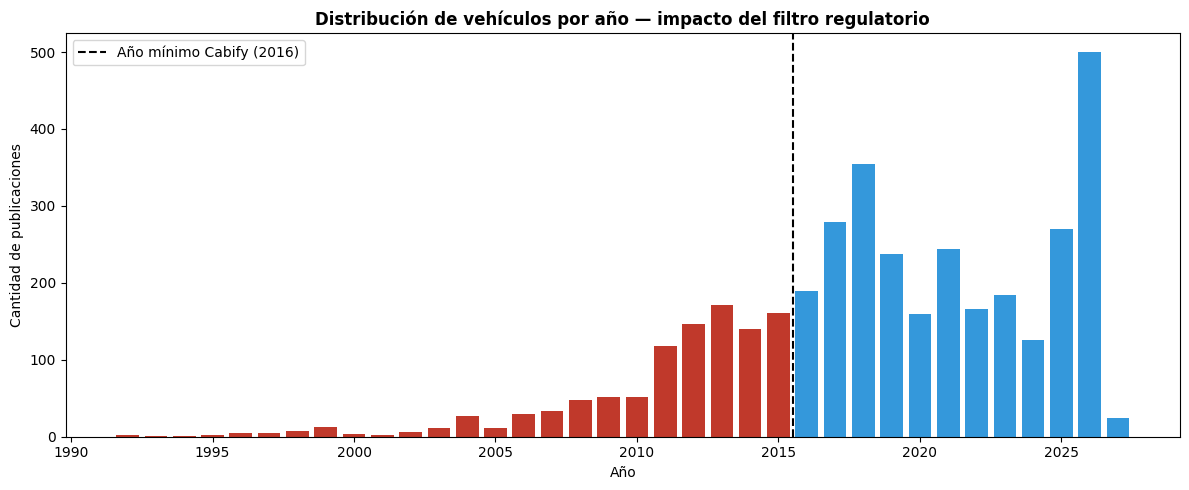

Gráfico de distribución por año guardado en reports/figures/


In [5]:
# Distribución de publicaciones por año — visualiza el impacto del filtro regulatorio.
# df_raw se copió al leer el dataset crudo (antes del filtro de año), así que conserva
# las unidades pre-2016 que fueron descartadas. Si por algún motivo no existe, usamos df.
conteo_anios = (
    df_raw["año"].value_counts().sort_index()
    if "df_raw" in globals()
    else df["año"].value_counts().sort_index()
)

plt.figure(figsize=(12, 5))
colores = ["#c0392b" if a < año_minimo else "#3498db" for a in conteo_anios.index]
plt.bar(conteo_anios.index, conteo_anios.values, color=colores)
plt.axvline(año_minimo - 0.5, color="black", linestyle="--", linewidth=1.5,
            label=f"Año mínimo Cabify ({año_minimo})")
plt.title("Distribución de vehículos por año — impacto del filtro regulatorio", fontweight="bold")
plt.xlabel("Año")
plt.ylabel("Cantidad de publicaciones")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/01b_distribucion_anios.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico de distribución por año guardado en reports/figures/")

### Hallazgo post-filtro

Eliminar los autos pre-2016 reveló que los modelos que lideraban el ranking
de rentabilidad (**VW Gol, Fiat Siena, VW Voyage**) tenían su bajo precio
mediano explicado principalmente por unidades viejas no elegibles para Cabify.

Con el filtro aplicado:
- VW Gol pasó de 240 a **12 publicaciones elegibles**
- Fiat Siena de 221 a **66**
- VW Voyage de 227 a **59**

Adicionalmente, los modelos que fueron excluidos anteriormente por tener
km mediano cercano a 0 (**Fiat Cronos, VW Virtus, Chevrolet Onix Plus**)
ahora tienen representación significativa (180-240 registros) y deben
ser reincorporados al análisis — su "novedad" es una ventaja, no un problema.

### Detección y eliminación de outliers — Método IQR

Usamos el **rango intercuartílico (IQR)** en lugar de umbrales fijos porque:
- Un umbral fijo ("saco todo lo que tenga más de 300.000 km") es arbitrario
- El IQR usa la distribución real de cada variable para definir qué es anómalo
- Es reproducible y estadísticamente justificable

La regla: cualquier valor fuera de `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]` se considera outlier.

In [6]:
def filtrar_outliers_iqr(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    return df[(df[columna] >= limite_inf) & (df[columna] <= limite_sup)]

registros_antes = len(df)

df = filtrar_outliers_iqr(df, "precio_usd")
df = filtrar_outliers_iqr(df, "km_num")

registros_despues = len(df)

print(f"Registros antes: {registros_antes}")
print(f"Registros después: {registros_despues}")
print(f"Outliers eliminados: {registros_antes - registros_despues}")
print(f"\nRango de precios USD: ${df['precio_usd'].min():,.0f} — ${df['precio_usd'].max():,.0f}")
print(f"Rango de km: {df['km_num'].min():,.0f} — {df['km_num'].max():,.0f}")

Registros antes: 2733
Registros después: 2678
Outliers eliminados: 55

Rango de precios USD: $2,500 — $33,200
Rango de km: 0 — 243,000


### Análisis exploratorio visual

Antes de modelar, visualizamos para entender la forma real de los datos.
Los promedios solos pueden ocultar patrones importantes — un boxplot muestra 
dispersión, asimetría y outliers que un número simple no revela.

C:\Users\Franco\AppData\Local\Temp\ipykernel_21452\1301093875.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot(bp_data, labels=[m.replace("Chevrolet ", "Chev. ").replace("Toyota ", "Toy. ").replace("Renault ", "Ren. ").replace("Peugeot ", "Peug. ") for m in modelos_orden], vert=False)


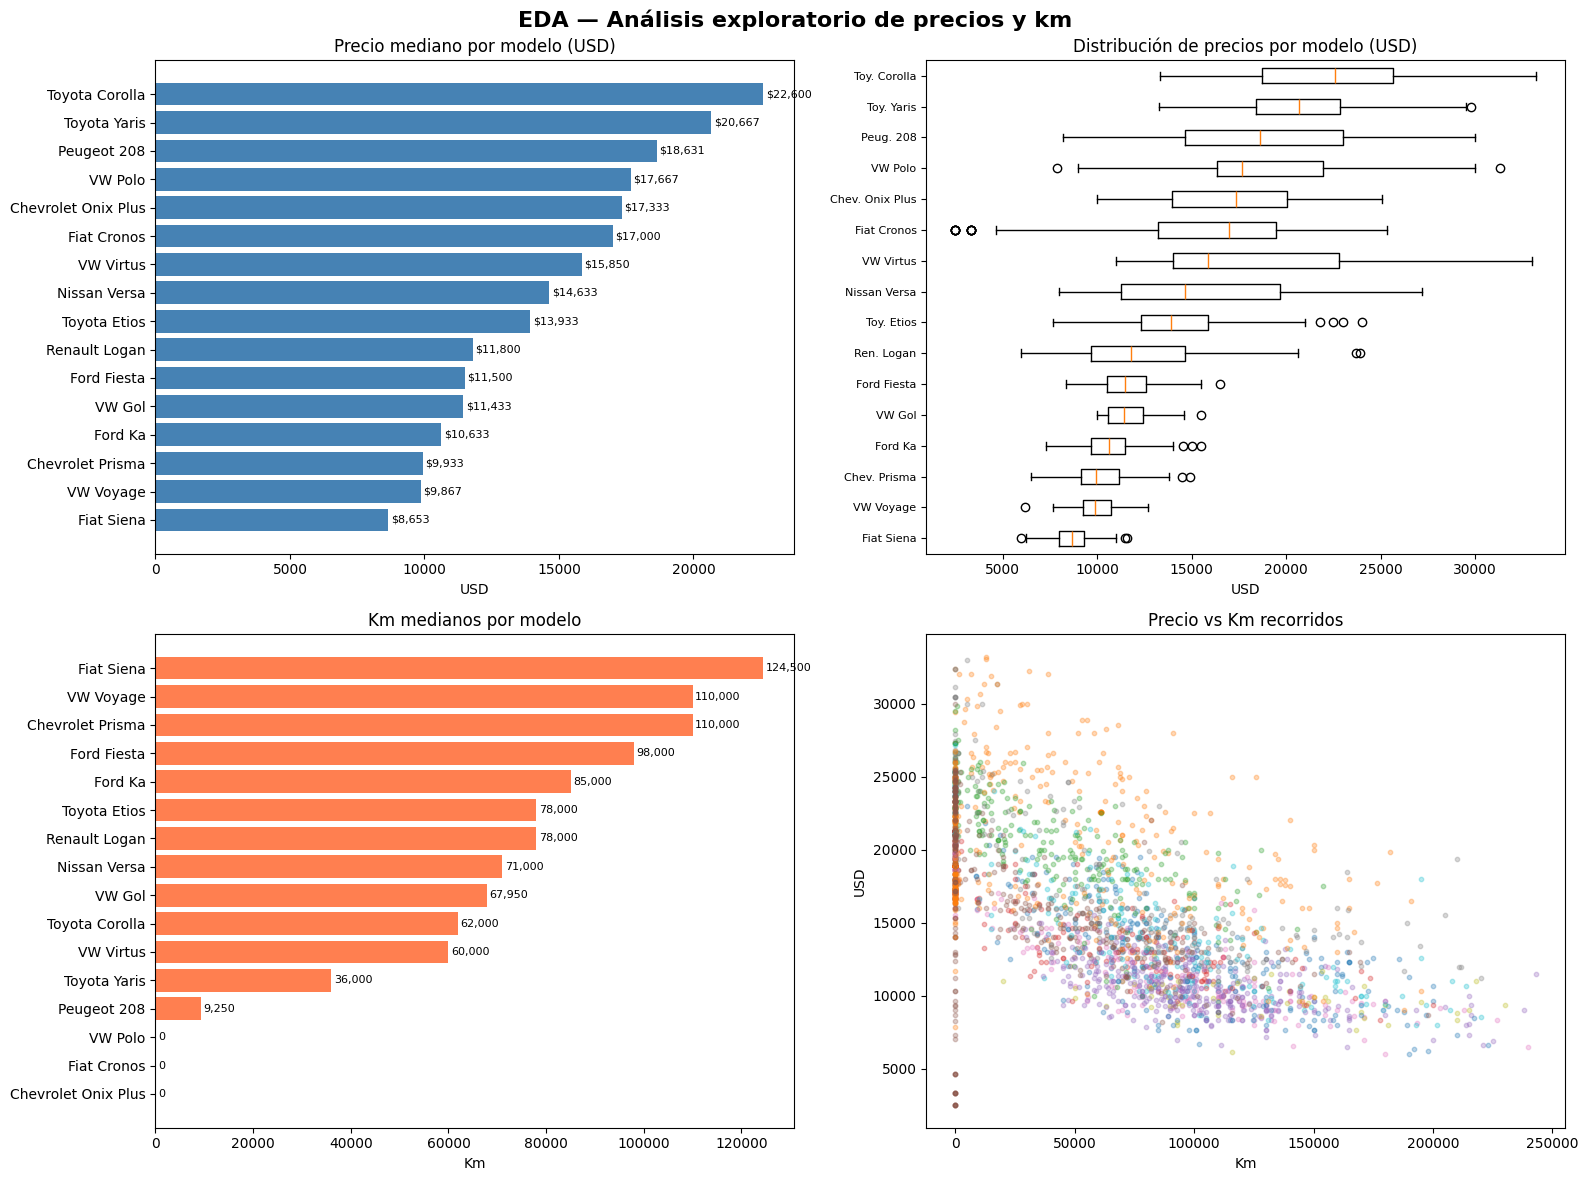

Gráfico guardado en reports/figures/


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("EDA — Análisis exploratorio de precios y km", fontsize=16, fontweight="bold")

# 1. Precio promedio por modelo
precio_promedio = df.groupby("modelo")["precio_usd"].median().sort_values(ascending=True)
axes[0, 0].barh(precio_promedio.index, precio_promedio.values, color="steelblue")
axes[0, 0].set_title("Precio mediano por modelo (USD)")
axes[0, 0].set_xlabel("USD")
for i, v in enumerate(precio_promedio.values):
    axes[0, 0].text(v + 100, i, f"${v:,.0f}", va="center", fontsize=8)

# 2. Distribución de precios por modelo — boxplot
modelos_orden = precio_promedio.index.tolist()
df_plot = df[df["modelo"].isin(modelos_orden)]
bp_data = [df_plot[df_plot["modelo"] == m]["precio_usd"].values for m in modelos_orden]
axes[0, 1].boxplot(bp_data, labels=[m.replace("Chevrolet ", "Chev. ").replace("Toyota ", "Toy. ").replace("Renault ", "Ren. ").replace("Peugeot ", "Peug. ") for m in modelos_orden], vert=False)
axes[0, 1].set_title("Distribución de precios por modelo (USD)")
axes[0, 1].set_xlabel("USD")
axes[0, 1].tick_params(axis="y", labelsize=8)

# 3. Km promedio por modelo
km_promedio = df.groupby("modelo")["km_num"].median().sort_values(ascending=True)
axes[1, 0].barh(km_promedio.index, km_promedio.values, color="coral")
axes[1, 0].set_title("Km medianos por modelo")
axes[1, 0].set_xlabel("Km")
for i, v in enumerate(km_promedio.values):
    axes[1, 0].text(v + 500, i, f"{v:,.0f}", va="center", fontsize=8)

# 4. Scatter precio vs km
for modelo in df["modelo"].unique():
    subset = df[df["modelo"] == modelo]
    axes[1, 1].scatter(subset["km_num"], subset["precio_usd"], alpha=0.3, s=10, label=modelo)
axes[1, 1].set_title("Precio vs Km recorridos")
axes[1, 1].set_xlabel("Km")
axes[1, 1].set_ylabel("USD")

plt.tight_layout()
plt.savefig("../reports/figures/01_eda_exploratorio.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado en reports/figures/")

### Hallazgos del EDA

- **Toyota Corolla (~$22.600) y Toyota Yaris (~$20.700)** son los modelos más caros,
  con amplia dispersión de precios por la variedad de años y versiones disponibles.
- **Fiat Siena (~$8.650), VW Voyage (~$9.900) y Chevrolet Prisma (~$9.900)** son ahora
  los más baratos del análisis. El VW Gol dejó de ser el modelo más accesible: con el
  filtro regulatorio quedó en ~$11.400 y con solo 12 publicaciones elegibles.
- **Correlación negativa precio-km:** a mayor kilometraje, menor precio. Esto valida
  que usaremos km como variable clave en el modelo de depreciación.
- **Fiat Cronos y Chevrolet Onix Plus** mantienen km medianos cercanos a 0 incluso
  post-filtro: su mercado está compuesto por unidades nuevas o casi nuevas (año mediano
  2025), lo que explica sus precios elevados (~$17.000-$17.300). Ya no es motivo de
  exclusión — son autos nuevos con mercado real, no datos anómalos.

### Revisión de modelos incluidos en el análisis

En el EDA inicial excluí el **VW Polo, Fiat Cronos y Chevrolet Onix Plus**
por tener km mediano cercano a 0 — interpretando que no tenían mercado de
usados representativo.

Sin embargo, al aplicar el filtro de año ≥ 2016 este criterio cambió
completamente. Esos modelos tienen km mediano bajo **porque son autos nuevos**,
no porque el mercado sea irrelevante. Con el filtro aplicado, Fiat Cronos
(239 registros) y Chevrolet Onix Plus (179 registros) tienen representación
más que suficiente para el análisis.

**Decisión revisada:** reincorporé Fiat Cronos y Chevrolet Onix Plus.
Solo excluí el **VW Polo** que quedó con muy pocos registros elegibles
tras el filtro de año.

Quedan **15 modelos** en el análisis con un total de **2.440 registros**.

> Este es un ejemplo de cómo una decisión de limpieza puede cambiar
> al incorporar contexto del dominio de negocio — el filtro regulatorio
> reveló que nuestra exclusión original tenía una premisa incorrecta.

In [8]:
# Con el filtro de año >= 2016, los modelos con km mediano 0
# ahora tienen representación adecuada y se reincorporan al análisis.
# Solo excluimos VW Polo por seguir teniendo pocas publicaciones elegibles.

modelos_excluir = ["VW Polo"]

df = df[~df["modelo"].isin(modelos_excluir)]

print(f"Modelos excluidos: {modelos_excluir}")
print(f"Registros restantes: {len(df)}")
print(f"\nModelos en análisis:")
print(df["modelo"].value_counts().sort_values(ascending=False))

Modelos excluidos: ['VW Polo']
Registros restantes: 2440

Modelos en análisis:
modelo
Fiat Cronos            239
Toyota Yaris           235
VW Virtus              233
Peugeot 208            224
Nissan Versa           214
Toyota Etios           209
Renault Logan          193
Chevrolet Prisma       187
Toyota Corolla         183
Chevrolet Onix Plus    179
Ford Ka                177
Fiat Siena              59
VW Voyage               55
Ford Fiesta             41
VW Gol                  12
Name: count, dtype: int64


In [9]:
# Guardo el dataset canónico definitivo — única fuente de verdad para 03, 04, 05 y el dashboard
df.to_csv("../data/processed/precios_autos_procesado.csv", index=False)
print(f"Dataset canónico guardado: {len(df)} registros, {df['modelo'].nunique()} modelos")
print(f"\nRegistros por modelo:")
print(df["modelo"].value_counts().sort_values(ascending=False))

Dataset canónico guardado: 2440 registros, 15 modelos

Registros por modelo:
modelo
Fiat Cronos            239
Toyota Yaris           235
VW Virtus              233
Peugeot 208            224
Nissan Versa           214
Toyota Etios           209
Renault Logan          193
Chevrolet Prisma       187
Toyota Corolla         183
Chevrolet Onix Plus    179
Ford Ka                177
Fiat Siena              59
VW Voyage               55
Ford Fiesta             41
VW Gol                  12
Name: count, dtype: int64
